# Chapter 7. Dimensionality Reduction

In [1]:
from sklearn.datasets import fetch_openml, make_swiss_roll
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection
from sklearn.manifold import LocallyLinearEmbedding

Dimensionality reduction 
- will usually speed up training
- can help data visualization
- but may not always improve model performance (depends on the datasets)
<br>

Of note: Adding an extra preprocessing step for dimensionality reduction will not always help. Some models (e.g., neural networks) can handle high-dimensional data efficiently and learn to reduce its dimensionality while preserving the useful information for the task at hand.

## 1. The Curse of Dimensionality

High-dimensional datasets are often very sparse: most training instances are likely to be far away from each other, so training methods based on distance or similarity (e.g., K-nearest neighbors) will be much less effective, and some models will not be useful at all because they scale poorly with dimensionality (SVM or dense neural networks).

# 2. Main Approaches for Dimensionality Reduction

### 2.1. Projection

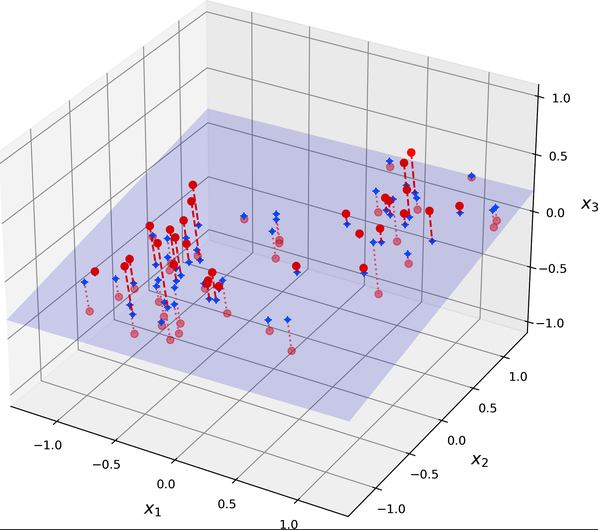

### 2.2. Manifold Learning

Although projection is fast and often works well, it is not always the best approach to dimensionality reduction. Alternatively, we can perform manifold.
- a 2D manifold is a 2D shape that can be bent and twisted in a higher-dimensional space.
- a d-dimensional manifold is a part of n-dimensional space (where d < n) that locally resembles a d-dimensional hyperplane.


Many dimensionality reduction algorithms work by modeling the manifold on which the training instances lie, which is called ***manifold learning***. It relies on the ***manifold assumption/hypothesis***, which holds that most real-world high-dimensional datasets lie close to a much lower-dimensional manifold. This assumption is very often empirically observed, but may not always hold.
<br>
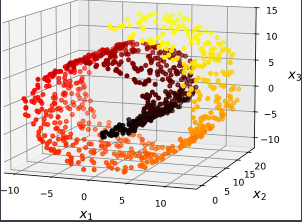
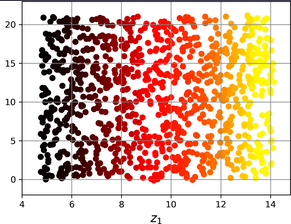
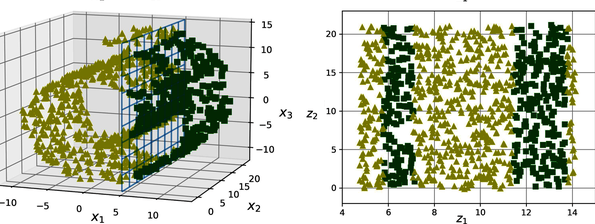

## 3. PCA

### 3.1. Preserving the Variance

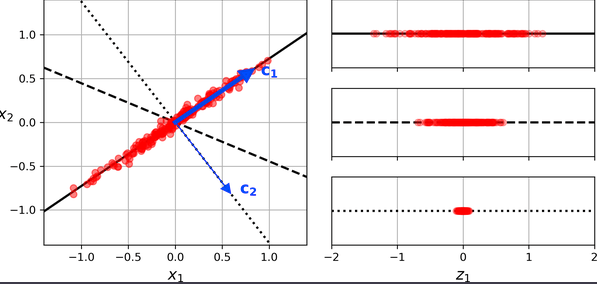

### 3.2. Principal Components

***Principal component analysis (PCA)*** identifies the axis (i.e., ***the first principal component***) that accounts for the largest amount of variance in the training set. Then it finds a second axis, **orthogonal** to the first one, that accounts for the largest amount of the **remaining variance**. Then a third axis, orthogonal to both previous axes, and a fourth... as many axes as the number of dimensions in the dataset.

For each principal component, PCA finds a zero-centered unit vector pointing along the direction of the PC. Unfortunately, its direction is not guaranteed: if you perturb the training set slightly and run PCA again, the unit vector may point in the opposite direction. In fact, a pair of unit vectors may even rotate or swap if the variances along these two axes are very close. So if you use PCA as a preprocessing step before a model, make sure you always retrain the model entirely every time you update the PCA transformer: if you don’t and if the PCA’s output doesn’t align with the previous version, the model will be very confused.

### 3.3. Projecting Down to Dimensions

### 3.4. Using Scikit-Learn

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)

PCA()

### 3.5. Explained Variance Ratio

The ratio indicates the proportion of the dataset’s variance that lies along each principal component

In [3]:
pca.explained_variance_ratio_[:10]

array([0.09704664, 0.07095924, 0.06169089, 0.05389419, 0.04868797,
       0.04312231, 0.0327193 , 0.02883895, 0.02762029, 0.02357001])

### 3.6. Choosing the Right Number of Dimension

Instead of arbitrarily choosing the number of dimensions to reduce down to, it is simpler to choose the number of dimensions that add up to a sufficiently large portion of the variance—say, 95%. (Of course, if you are reducing dimensionality for data visualization, in which case you will want to reduce the dimensionality down to 2 or 3.)

In [4]:
cumsum = np.cumsum(pca.explained_variance_ratio_)
np.argmax(cumsum >= 0.95) + 1  

np.int64(154)

We can directly specifying the number of principal components we want to preserve by setting `n_components` to be a float between 0 and 1

In [5]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)
X_reduced.shape

(60000, 154)

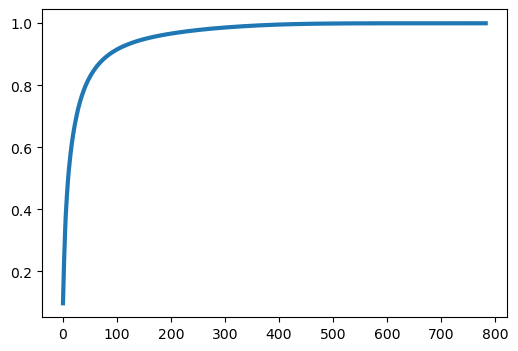

In [6]:
plt.figure(figsize=(6,4))
plt.plot(cumsum, linewidth = 3)

### 3.7. PCA for Compression

We can decompress the reduced dataset back to the original dimensions by applying the inverse transformation of the PCA projection. This won't give us back the original data, since projection lost some information (in our example, ~5% variance). The mean squared distance between the original data and the reconstructed data is called the ***reconstruction error***.

In [7]:
X_recovered = pca.inverse_transform(X_reduced)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

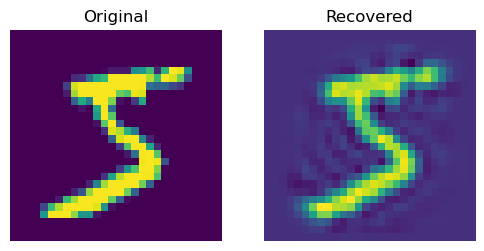

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize = [6, 3])

axes[0].imshow(X_train[0].reshape(28, 28))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(X_recovered[0].reshape(28, 28))
axes[1].set_title("Recovered")
axes[1].axis("off")

### 3.8. Randomized PCA

If you set the `svd_solver` hyperparameter to "randomized", Scikit-Learn uses a stochastic algorithm called ***randomized PCA*** that quickly finds an approximation of the first d principal components. Its computational complexity is O(m × d2) + O(d3), instead of O(m × n2) + O(n3) for the full SVD approach, so it is **dramatically faster than full SVD when d is much smaller than n**

In [20]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

### 3.9. Incremental PCA

The preceding PCA implementations require the whole training set to fit in memory in order for the algorithm to run. Fortunately, ***incremental PCA (IPCA)*** algorithms have been developed that allow you to **split the training set into mini-batches and feed theese in one mini-batch at a time**, which is useful for large training sets and for applying PCA **online**. 
<br>

Incremental PCA keeps the principal components consistent across batches by using each mini-batch to update one shared global set of components, and all data should be transformed only after the final partial_fit() is complete.

In [ ]:
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, 100):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

For very high-dimensional datasets (e.g., images), PCA can be too slow. In this case, we should consider using random projection instead.

## 4. Random Projection

***Random projection*** projects the data to a low-dimensional space using a random **linear** projection. It turns out that such a random projection is actually very likely to preserve distance fairly well. There is an equation that **determines the minimum number of dimensions to preserve** in order to ensure - with high probability - that distances won't change by more than a give tolerance (ε = 10%). The equation does not use n (the number of features), it only relies on 
- sample size (m)
- tolerance (ε) [epsilon]
<br>

Random projection is a simple, fast, memory-efficient, and surprisingly powerful dimensionality reduction algorithm that we should keep in mind, especially when we deal with high-dimensional datasets. Random projection loses a bit more signal than PCA, so there is a trade-off between training speed and performance. 

In [23]:
m, ε = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=ε)
d

np.int64(7300)

We can just generate a random matrix P of shape [d, n], where each item is sampled randomly from a Guassian distribution with mean 0 and variance 1/d, and use it to project a dataset from n dimensions down to d

In [24]:
n = 20_000
rng = np.random.default_rng(seed=42)
P = rng.standard_normal((d, n)) / np.sqrt(d)  # std dev = sqrt(variance)

X = rng.standard_normal((m, n))  # generate a fake dataset
X_reduced = X @ P.T
X_reduced.shape

(5000, 7300)

Scikit-Learn offers a `GaussianRandomProjection` class to do exactly what we just did: when you call its fit() method, it uses `johnson_lindenstrauss_min_dim()` to determine the output dimensionality, then it generates a random matrix, which it stores in the components_ attribute. Then when you call `transform()`, it uses this matrix to perform the projection. When creating the transformer, you can set `eps` to tweak ε (it defaults to 0.1), and `n_components` to force a specific target dimensionality d (you will probably want to fine-tune these hyperparameters using cross-validation). 

In [ ]:
gaussian_rnd_proj = GaussianRandomProjection(eps=ε, random_state=32)
X_reduced = gaussian_rnd_proj.fit_transform(X)  # same result as above

## 5. Locally Linear Embedding (LLE)

LLE is a **nonlinear dimensinality reduction (NLDR)** technique. It is a manifold learning technique. In short, LLE first determines how each training instance linearly relates to its nearest neighbors, then it looks for a low-dimensional representation of the training set where these local relationships are best preserved.
- LLE is good at unrolling twisted manifolds, especially when there is not too much noise.
- LLE does not scale well, so it is mostly for small or medium sized datasets.

In [2]:
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=32)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=32)
X_unrolled = lle.fit_transform(X_swiss)

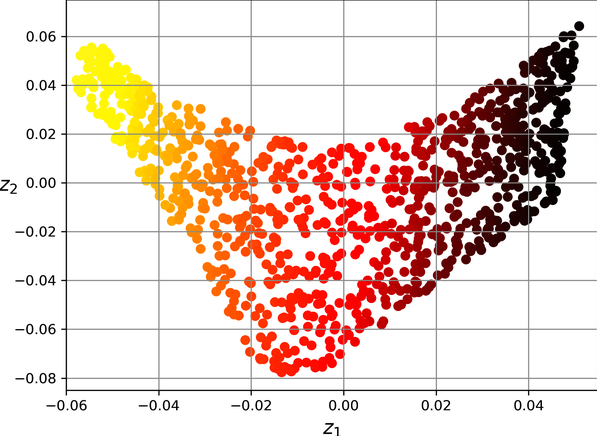

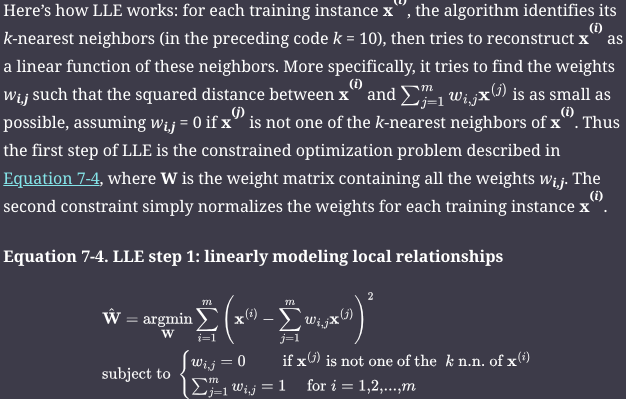

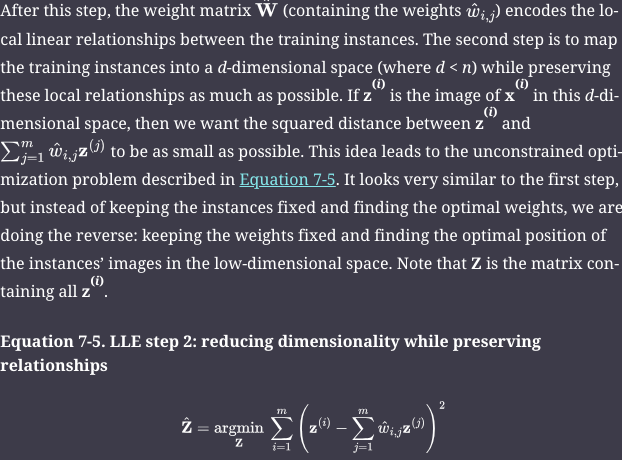

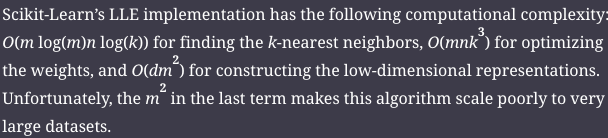

## 6. Other Dimensionality Reduction Techniques

***`sklearn.manifold.MDS`***: Multidimensional scaling (MDS) reduces dimensionality while trying to preserve the distances between the instances. Random projection does that for high-dimensional data, but it does not work well on low-dimensional data.
<br>

***`sklearn.manifold.Isomap`***: Isomap creates a graph by connecting each instance to its nearest neighbors, then reduces dimensionality while trying to preserve the geodesic distances between the instances. The ***geodesic distance*** between two nodes in a graph is the number of nodes on the shortest path between these nodes. This approach works best when the data lies on a fairly smooth and low-dimensional manifold with a single global structure.
<br>

***`sklearn.manifold.TSNE`***: t-distributed stochastic neighbor embedding (t-SNE) reduces dimensionality while trying to keep similar instances close and dissimilar instances apart. **It is mostly used for visualization**, in particular to visualize clusters of instances in high-dimensional space. For example, in the exercises at the end of this chapter you will use t-SNE to visualize a 2D map of the MNIST images. However, it is not meant to be used as a preprocessing stage for an ML model.


***`sklearn.discriminant_analysis.LinearDiscriminantAnalysis`***: Linear discriminant analysis (LDA) is a linear classification algorithm that, during training, learns the most discriminative axes between the classes. These axes can then be used to define a hyperplane onto which to project the data. The benefit of this approach is that the projection will keep classes as far apart as possible, so ***LDA is a good technique to reduce dimensionality before running another classification algorithm*** (unless LDA alone is sufficient).

***Uniform Manifold Approximation and Projection (UMAP)*** is another popular dimensionality reduction technique for visualization. While t-SNE is better at preserving the local structure, especially clusters, UMAP tries to preserve both the local and global structures. Moreover, it scales better to large datasets. Till now, it is not available in Scikit-learn.